# Understanding Leave-One-Out Probability Integral Transform (LOO-PIT)

## Introduction

Model calibration is a critical characteristic for any model that produces probabilistic outputs. For Bayesian models, which yield full distributions rather than point estimates, calibration is especially important.  The reliability of these predictive distributions determines how well these models will generalize to unseen data.


## An Obscure Result in Statistics

A brief scenario consisting of the following steps can cement an understanting of Probability Integral Tranform (PIT). 
1. Consider a probability distribution $G$, and its corresponding PIT. 
2. Sample many values $X$ from this distribution; $X \sim G$
3. Put each through the CDF of this same distribution to get the area under the curve corresponding each, $U=F(X)$
4. You'll find $U$ is uniformly distributed; $U\in [0, 1]$ 


In [46]:
import numpy as np
import matplotlib.pyplot as pp
import scipy.stats as st
import pymc as pm
import arviz as az

In [ ]:
def make_scxenarios():

    calibrated = dict(
    model_pred_mean=0, model_pred_sd=1,
    obs_mean=0, obs_scale=1
    )

    underdispersed = dict(
        model_pred_mean=0, model_pred_sd=1,
        obs_mean=0, obs_scale=2
    )

    overdispersed = dict(
        model_pred_mean=0, model_pred_sd=2,
        obs_mean=0, obs_scale=1
    )

    biased_high = dict(
        model_pred_mean=1, model_pred_sd=1,
        obs_mean=0, obs_scale=1
    )

    biased_low = dict(
        model_pred_mean=-1, model_pred_sd=1,
        obs_mean=0, obs_scale=1
    )
    return dict(calibrated=calibrated, underdispersed=underdispersed, overdispersed=overdispersed, biased_high=biased_high)

In [100]:
scenarios = make_scxenarios()
simulated_data = np.random.normal(loc=scenarios['calibrated']['obs_mean'], scale=scenarios['calibrated']['obs_scale'], size=1000)


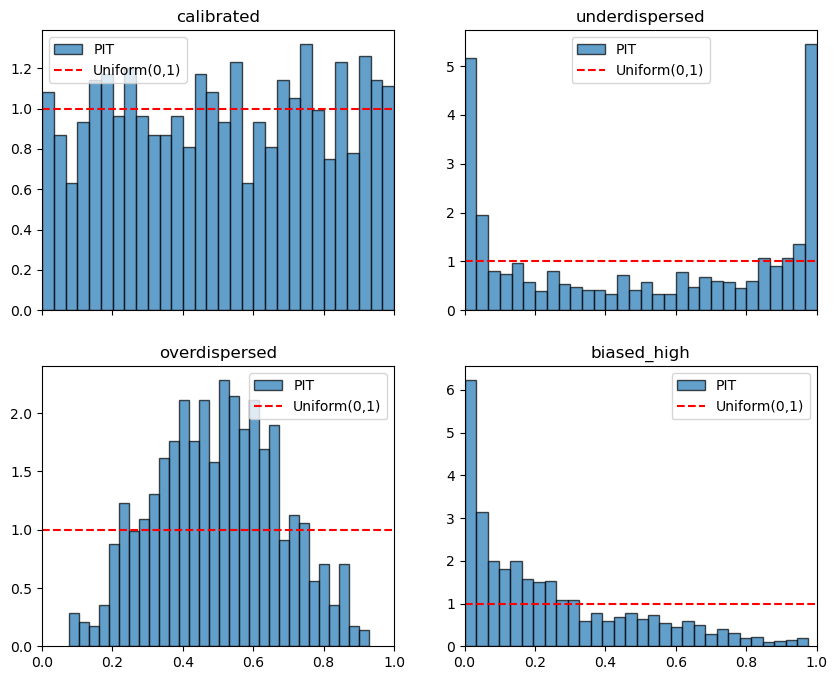

In [ ]:
def plot_scenario(scenario_payload: dict, scenario_name: str, ax):
    obs_loc = scenario_payload.pop('obs_mean')
    obs_scale = scenario_payload.pop('obs_scale')
    model_loc = scenario_payload.pop('model_pred_mean')
    model_scale = scenario_payload.pop('model_pred_sd')

    simulated = np.random.normal(loc=obs_loc, scale=obs_scale, size=1000)
    pit_vals = st.norm.cdf(simulated, loc=model_loc, scale=model_scale)

    ax.hist(pit_vals, bins=30, density=True, edgecolor='black', alpha=0.7, label='PIT')
    ax.set_xlim(0, 1)
    ax.set_title(scenario_name)
    ax.axhline(1.0, color='red', linestyle='--', label='Uniform(0,1)')
    ax.legend()

    
f, axs = pp.subplots(ncols=3, nrows=2, figsize=(10, 8), sharex=True)
for ax, (scenario_name, scenario) in zip(axs.ravel(), scenarios.items()):
    plot_scenario(scenario_payload=scenario, scenario_name=scenario_name, ax=ax)
f.savefig('PIT-demo.png', dpi=300)

Figure 1 - ***Top left***: PIT of the same distribution is an approximately uniform distribution. ***Top right***: PIT underdispersion - recognizable by the <u>u</u> shape of the PIT distribution - results from data sampled from a distribution with a higher variance than that of the PIT. ***Bottom left***: PIT overdispersion - regonizable by its <u>n</u> shape of the PIT distibution - results from  data sampled from a distribution with a lower variance than that of the PIT. ***Bottom right***: Biased (high) recognizable by the skewed shape (left if biased high, right if biased low) indicating PIT applied to a distribution with a mean that is higher or lower, respectively.


## Extending PIT to Bayesian Modeling

The accepted gold standard of model performance assessment and estimation of generalizability is the out-of-sample testing. This requires to split the data, after cleaning but before EDA, into train/test splits. Traditional train/test splitting, while common, is often wasteful and potentially harmful as issues such as bias can be inadvertently introduced. K-fold cross validation is used in frequentist machine learning to mitigate this, but is computationally costly for large models. In Bayesian modeling, where full posteriors are computed for prediction, this cost is prohibitive. Another possibility is that the data is scant requiring all the data to be used to maximize information. Fortunately, uncertainty-aware cross validation methods  - like the Widely Available Information Criterion (WAIC) and the Pareto-Smoothed Importance Sampling Leave One Out cross validation (PSIS-LOO) - allow the model to use all available data while still providing reliable assessments of generalization. PSIS-LOO is of interest here, as it effectively approximates LOO cross-validation and underlies the LOO-PIT method.


### PIT-LOO Steps

1. Train on $N-1$ observations, leave one out;
2. Predict on the left-out observation, getting a posterior predictive distribution — not a point prediction, but a full probability distribution over possible values;
3. Evaluate the CDF of that predictive distribution at the actual observed label (the held-out value);
4. This yields one value between 0 and 1 — the LOO-PIT value for that observation;
5. Repeat this for all $N$ observations, rotating the one left out each time;
6. Collect the $N$ LOO-PIT values, and compare their distribution to a Uniform(0, 1) distribution.
7. If comparison is good, the model is well calibrated.


Should the comparison be poor, however, the resulting diagnostic is indicative of the pathology afflicting the model
* Underdispersed - the model is overconfident, and predictive distributions are not wide enough
* Overdispersed - the model is too uncertaint, predictive distributions are too wide
* Biased - the model will produce consistently skewed predictions.

I explore what these look like next.

### Visual Interpretation How-to

To simulate LOO-PIT behavior under different model calibration scenarios, we draw synthetic observations from a known distribution and compare them to what the model believes the data should look like. The distribution we use to generate the observations is defined by obs_loc and obs_scale — this represents the data-generating process. The model’s predictive distribution is defined by model_loc and model_scale, and represents the beliefs the model would use when making predictions. By comparing how these two distributions differ — in width (dispersion) or center (bias) — we can observe how miscalibration shows up in the LOO-PIT histogram.

Below, I demonstrate the 4 corner stone cases - calibrated, overdispersed, underdispersed, biased (high). Each cased is modeled using my Probabilistic Programming framework of choice, PyMC, which simplifies the computation of the log-likelihood, itself necessary to compute the PSIS-LOO approximation required by LOO-PIT.

### Calibrated model

In [52]:
with pm.Model() as m_cal:
    mu = pm.Normal('mu', 0, 10)
    sd = pm.HalfNormal('sd', 10)
    lkl = pm.Normal('likelihood', mu=mu, sigma=sd, observed=simulated_data)
    idata_cal= pm.sample(chains=4, draws=1000)
    idata_cal.extend(pm.sample_posterior_predictive(idata_cal))
    pm.compute_log_likelihood(idata_cal, extend_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sd]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [likelihood]


Output()

Output()

Here's a graphic representation of this model

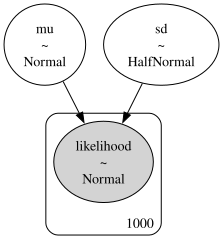

In [96]:
m_cal.to_graphviz()

In [74]:
def plot_pymc_calib_demo(idata, model_type: str, ax_pit_ylim=None):
    f = pp.figure(figsize=(12 ,9))
    ax_ppc = f.add_subplot(2, 1, 1)
    az.plot_ppc(idata, ax=ax_ppc, colors=['darkgray', 'k', 'C1'])
    ax_ppc.set_xlabel('')
    ax_pit = f.add_subplot(2, 2, 3)
    az.plot_loo_pit(idata, y='likelihood', ax=ax_pit)
    ax_pit.set_xlabel('')
    ax_pit.set_ylim(ax_pit_ylim)
    ax_pit_ecdf = f.add_subplot(2, 2, 4)
    az.plot_loo_pit(idata, y='likelihood', ax=ax_pit_ecdf, ecdf=True)
    ax_pit_ecdf.set_xlabel('')
    f.suptitle(f'{model_type} Model')
    f.tight_layout()
    return dict(
        fig_handle=f, ax_ppc_handle=ax_ppc, 
        ax_pit_handle=ax_pit, ax_pit_ecdf_handle=ax_pit_ecdf)

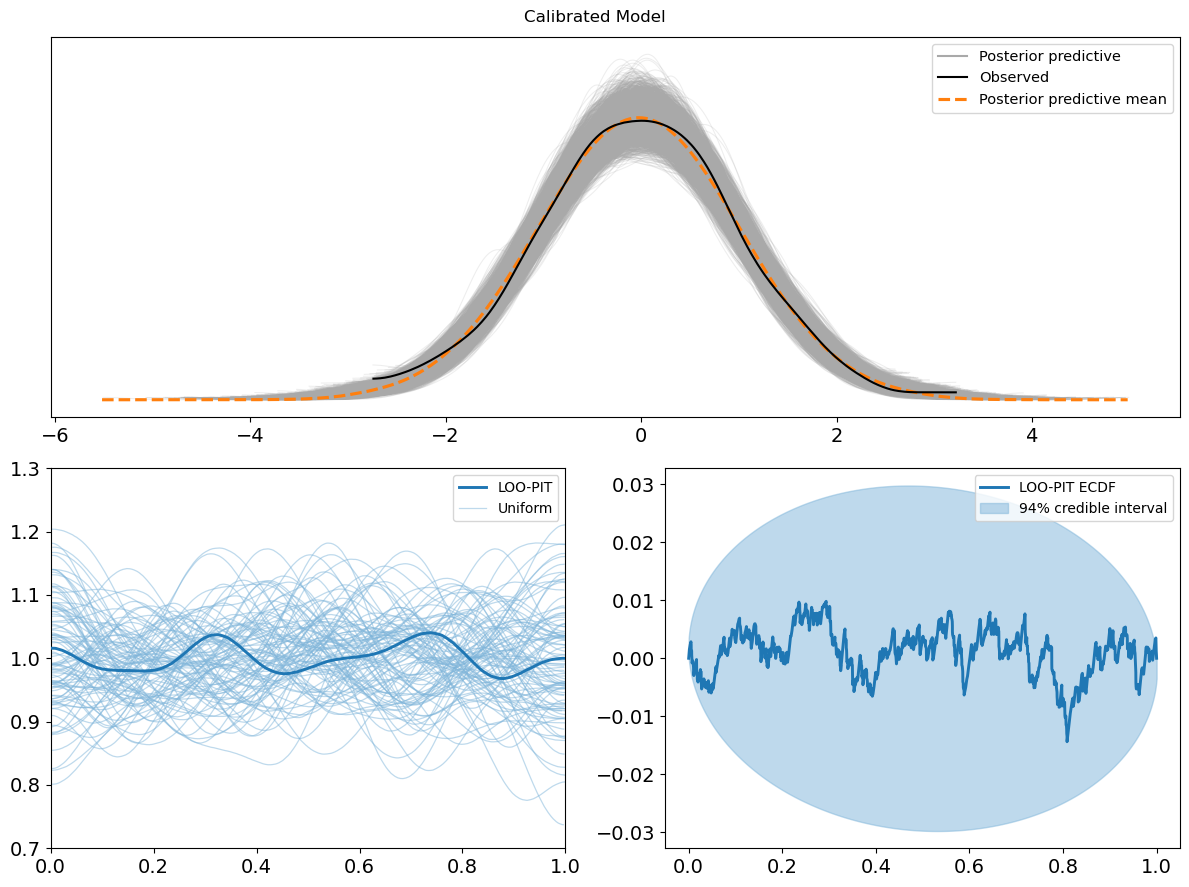

In [75]:
plot_payload = plot_pymc_calib_demo(idata_cal, model_type='Calibrated', ax_pit_ylim=(0.7, 1.3))

### Overdispersed model

In [77]:
sim_dat_ovd = np.random.normal(
    loc=overdispersed['obs_mean'], scale=overdispersed['obs_scale'], size=1000)
with pm.Model() as m_overdispersed:
    mu = pm.Normal('mu', 0, 10)
    lkl = pm.Normal('likelihood', mu=mu, sigma=overdispersed['model_pred_sd'], observed=sim_dat_ovd)
    idata_ovd= pm.sample(chains=4, draws=1000)
    idata_ovd.extend(pm.sample_posterior_predictive(idata_ovd))
    pm.compute_log_likelihood(idata_ovd, extend_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.
Sampling: [likelihood]


Output()

Output()

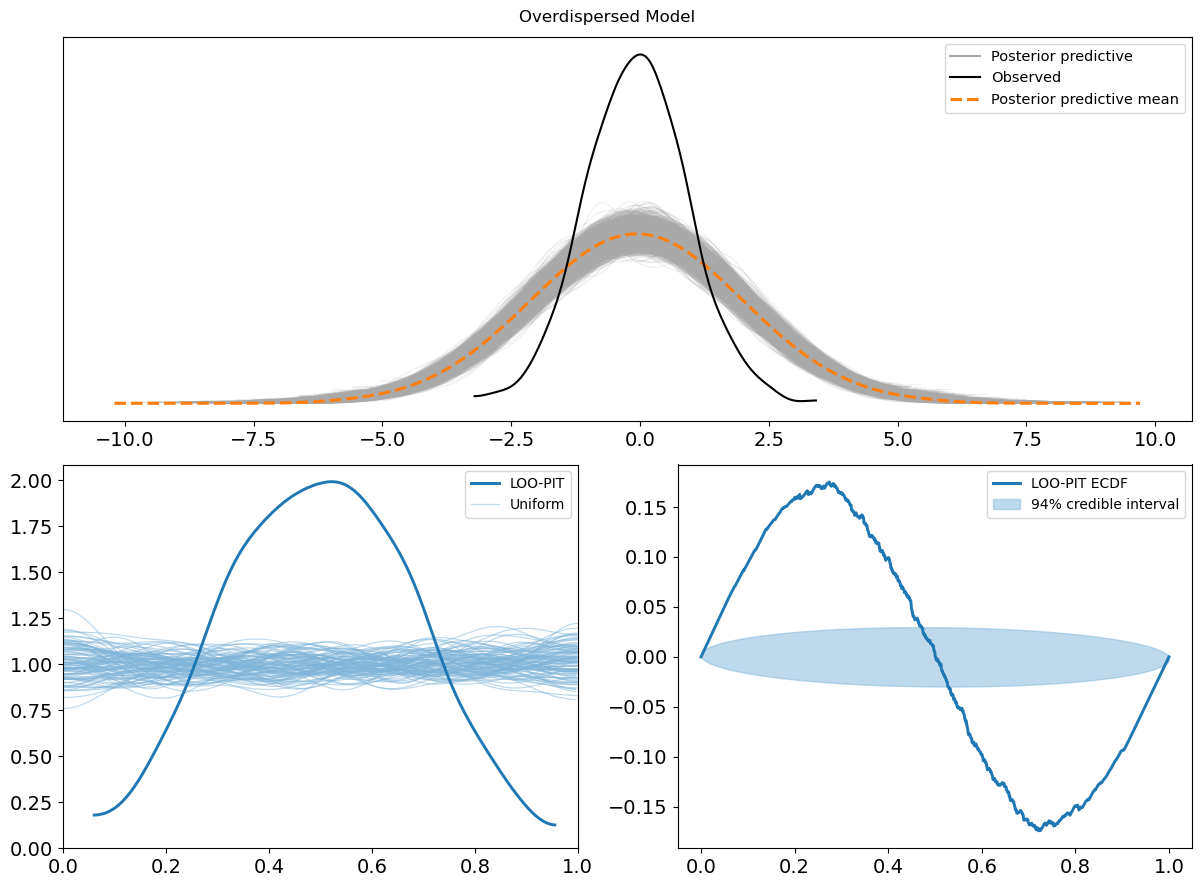

In [78]:
plot_payl_ovd = plot_pymc_calib_demo(idata_ovd, model_type='Overdispersed')

### Underdispersed Model

In [79]:
sim_dat_udd = np.random.normal(
    loc=underdispersed['obs_mean'], scale=underdispersed['obs_scale'], size=1000)
with pm.Model() as m_underdispersed:
    mu = pm.Normal('mu', 0, 10)
    lkl = pm.Normal('likelihood', mu=mu, sigma=underdispersed['model_pred_sd'], observed=sim_dat_udd)
    idata_udd= pm.sample(chains=4, draws=1000)
    idata_udd.extend(pm.sample_posterior_predictive(idata_udd))
    pm.compute_log_likelihood(idata_udd, extend_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [likelihood]


Output()

Output()

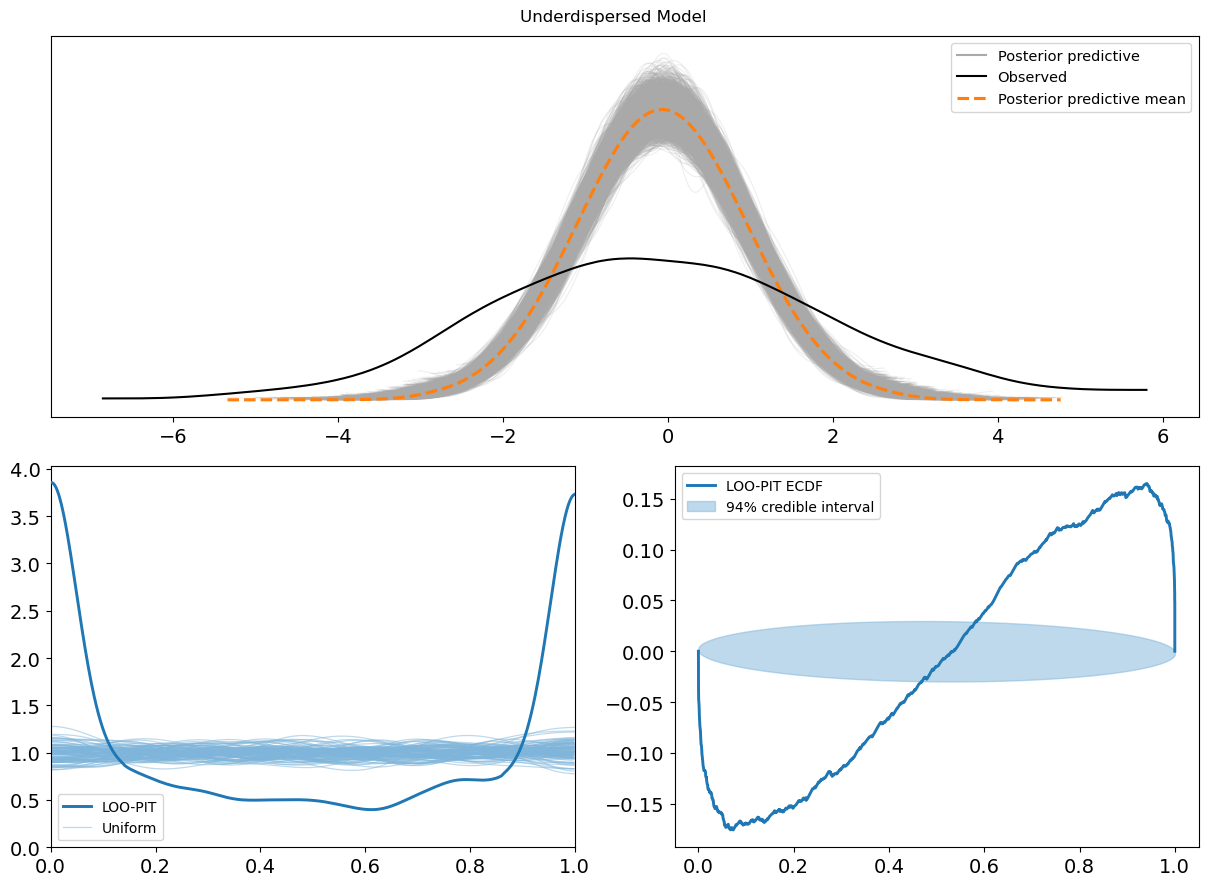

In [85]:
plot_payl_udd = plot_pymc_calib_demo(idata_udd, model_type='Underdispersed')

### Biased Model

In [81]:
sim_dat_bias = np.random.normal(
    loc=biased_high['obs_mean'], scale=biased_high['obs_scale'], size=1000) 

In [83]:
with pm.Model() as m_bias:
    sd = pm.HalfNormal('sd', 10)
    likelihood = pm.Normal(
        'likelihood', mu=biased_high['model_pred_mean'], sigma=sd, observed=sim_dat_bias)
    idata_bias = pm.sample(chains=4, draws=1000)
    idata_bias.extend(pm.sample_posterior_predictive(idata_bias))
    pm.compute_log_likelihood(idata_bias, extend_inferencedata=True)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sd]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.
Sampling: [likelihood]


Output()

Output()

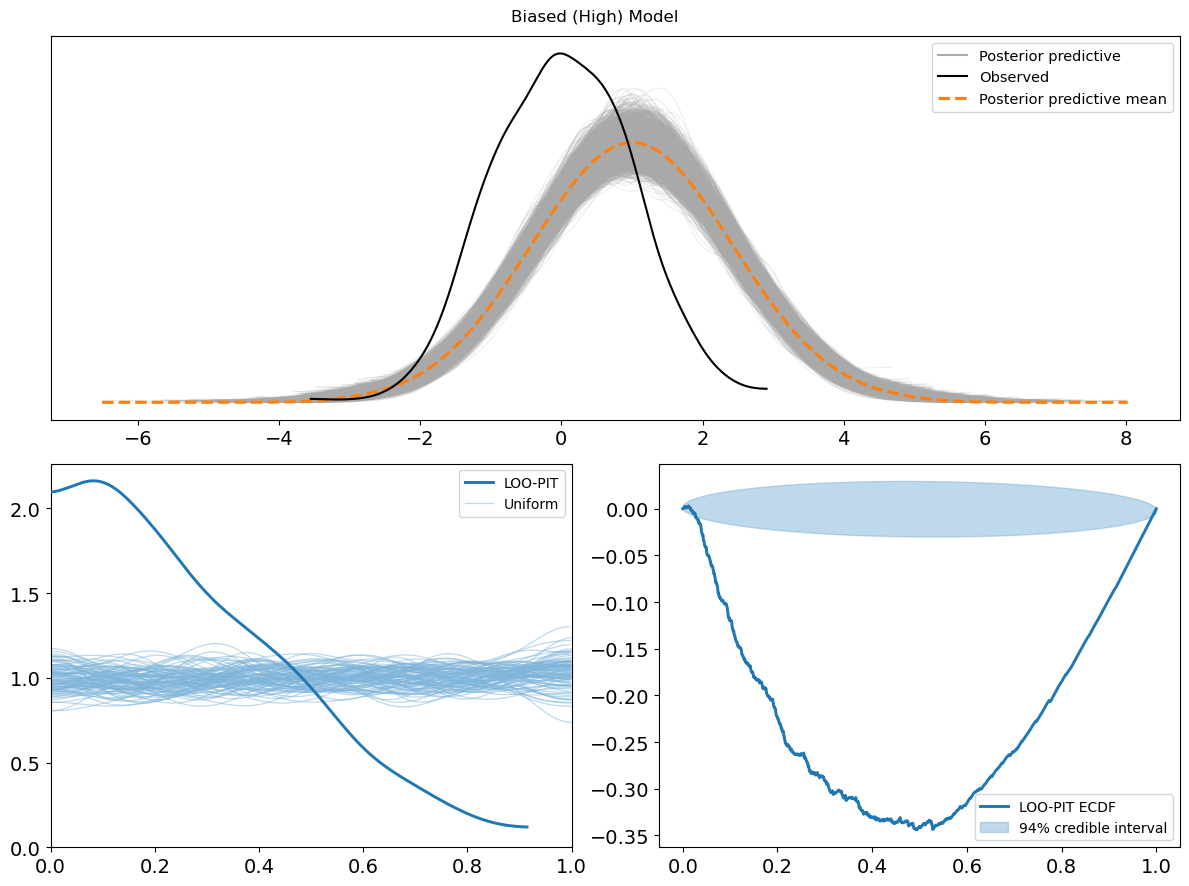

In [86]:
biased_payload = plot_pymc_calib_demo(idata_bias, model_type='Biased (High)')

Below I plot all scenarios together for easier comparison:
- Top row - PPC plots for all 4 scenarios. 
- Bottom row - LOO-PIT plots for all 4 scenarios

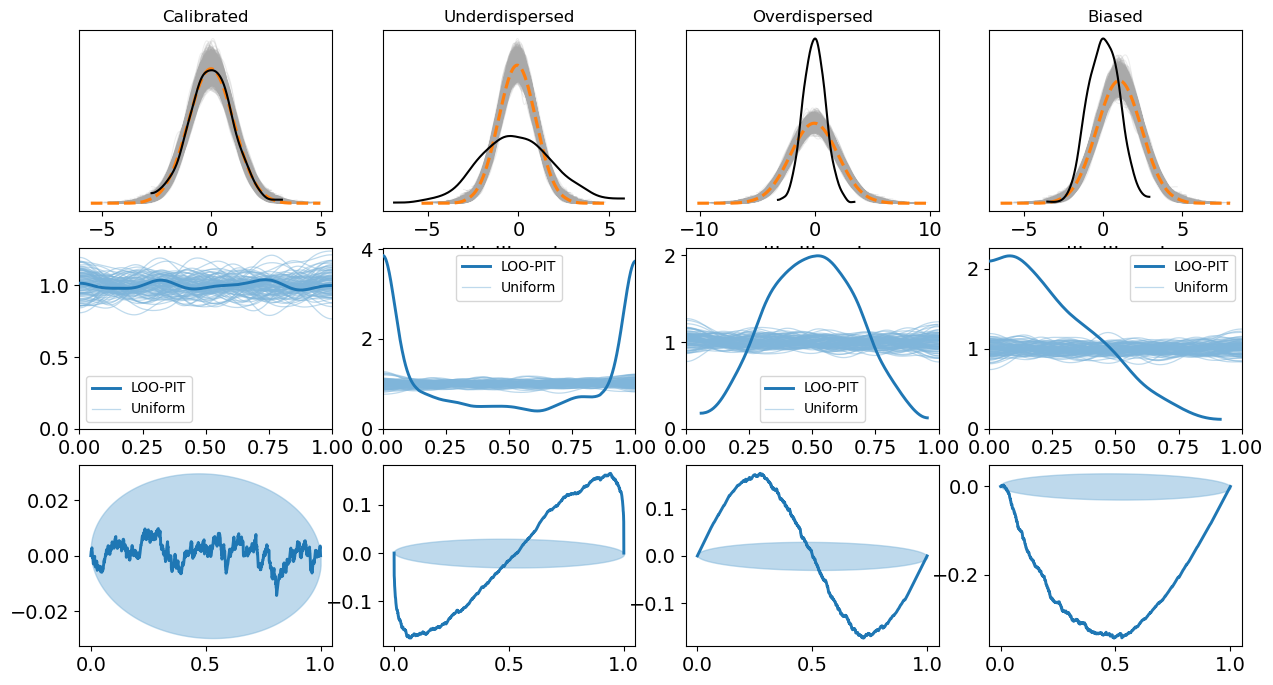

In [107]:
f, axs = pp.subplots(ncols=4, nrows=3, figsize=(15, 8))
idata_list = [idata_cal, idata_udd, idata_ovd, idata_bias]
scenario_names = ['Calibrated', 'Underdispersed', 'Overdispersed', 'Biased']
for ax, idata, sc_name in zip(axs[0,:], idata_list, scenario_names):
    az.plot_ppc(idata, ax=ax, colors=['darkgray', 'k', 'C1'], legend=False)
    ax.set_title(sc_name)
for ax, idata in zip(axs[1, :], idata_list):
    az.plot_loo_pit(idata, y='likelihood', ax=ax)
    ax.set_xlabel('')
for ax, idata in zip(axs[2,:], idata_list):
    az.plot_loo_pit(idata, y='likelihood', ax=ax, ecdf=True, legend=False)
    ax.set_xlabel('')
f.savefig('loo_pit_demo.png', dpi=300)


Note that there are 2-5 more possible scenarios depending on how you look at it; skewed (low, high) AND over/underdispersed. I invite the interested reader to explore that on their own. 

If you've come this far, thanks for your patience. 